In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pymysql
from sqlalchemy import create_engine

In [3]:
deliveries = pd.read_csv(r"C:\Users\Abhijit\Downloads\archive\deliveries.csv")
matches = pd.read_csv(r"C:\Users\Abhijit\Downloads\archive\matches.csv")

In [4]:
deliveries.head()


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [5]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [6]:
deliveries.shape

(260920, 17)

In [7]:
matches.shape

(1095, 20)

In [8]:
matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   str    
 2   city             1044 non-null   str    
 3   date             1095 non-null   str    
 4   match_type       1095 non-null   str    
 5   player_of_match  1090 non-null   str    
 6   venue            1095 non-null   str    
 7   team1            1095 non-null   str    
 8   team2            1095 non-null   str    
 9   toss_winner      1095 non-null   str    
 10  toss_decision    1095 non-null   str    
 11  winner           1090 non-null   str    
 12  result           1095 non-null   str    
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   str    
 17  method           21 non-n

In [9]:
deliveries.info()

<class 'pandas.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   match_id          260920 non-null  int64
 1   inning            260920 non-null  int64
 2   batting_team      260920 non-null  str  
 3   bowling_team      260920 non-null  str  
 4   over              260920 non-null  int64
 5   ball              260920 non-null  int64
 6   batter            260920 non-null  str  
 7   bowler            260920 non-null  str  
 8   non_striker       260920 non-null  str  
 9   batsman_runs      260920 non-null  int64
 10  extra_runs        260920 non-null  int64
 11  total_runs        260920 non-null  int64
 12  extras_type       14125 non-null   str  
 13  is_wicket         260920 non-null  int64
 14  player_dismissed  12950 non-null   str  
 15  dismissal_kind    12950 non-null   str  
 16  fielder           9354 non-null    str  
dtypes: int64(8), str(9)
m

In [10]:
matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [11]:
matches['city'] = matches['city'].fillna('Unknown')
matches['method'] = matches['method'].fillna('Normal Match')
matches['player_of_match'] = matches['player_of_match'].fillna('No Award')
matches['winner'] = matches['winner'].fillna('No Result')

# Numeric columns
matches['result_margin'] = matches['result_margin'].fillna(0)
matches['target_runs'] = matches['target_runs'].fillna(0)
matches['target_overs'] = matches['target_overs'].fillna(0)

In [12]:
matches.isnull().sum()

id                 0
season             0
city               0
date               0
match_type         0
player_of_match    0
venue              0
team1              0
team2              0
toss_winner        0
toss_decision      0
winner             0
result             0
result_margin      0
target_runs        0
target_overs       0
super_over         0
method             0
umpire1            0
umpire2            0
dtype: int64

In [13]:
matches.duplicated().sum()

np.int64(0)

In [14]:
matches.drop_duplicates(inplace = True)
deliveries.drop_duplicates(inplace = True)

In [15]:
matches['winner'].unique()

<StringArray>
[      'Kolkata Knight Riders',         'Chennai Super Kings',
            'Delhi Daredevils', 'Royal Challengers Bangalore',
            'Rajasthan Royals',             'Kings XI Punjab',
             'Deccan Chargers',              'Mumbai Indians',
               'Pune Warriors',        'Kochi Tuskers Kerala',
                   'No Result',         'Sunrisers Hyderabad',
     'Rising Pune Supergiants',               'Gujarat Lions',
      'Rising Pune Supergiant',              'Delhi Capitals',
                'Punjab Kings',              'Gujarat Titans',
        'Lucknow Super Giants', 'Royal Challengers Bengaluru']
Length: 20, dtype: str

In [16]:
# counting number of unique winner teams
matches['winner'].nunique()

20

In [17]:
matches['winner'] = matches['winner'].replace({
    'Royal Challengers Bangalore':'Royal Challengers Bengaluru',
    'Rising Pune Supergiants':'Rising Pune Supergiant',
    'Delhi Daredevils':'Delhi Capitals',
    'Kings XI Punjab':'Punjab Kings'
})


In [18]:
matches['season'] = matches['season'].astype(str)

matches['season'] = matches['season'].replace({
    '2007/08': '2008',
    '2009/10': '2010',
    '2020/21': '2020'
})

matches['season'] = matches['season'].astype(int)

In [19]:
# removing extra spaces
matches['winner'] = matches['winner'].str.strip()
matches['venue'] = matches['venue'].str.strip()
matches['city'] = matches['city'].str.strip()

In [20]:
matches['winner'].value_counts()

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bengaluru    123
Delhi Capitals                 115
Rajasthan Royals               112
Punjab Kings                   112
Sunrisers Hyderabad             88
Deccan Chargers                 29
Gujarat Titans                  28
Lucknow Super Giants            24
Rising Pune Supergiant          15
Gujarat Lions                   13
Pune Warriors                   12
Kochi Tuskers Kerala             6
No Result                        5
Name: count, dtype: int64

In [21]:
matches['date'] = pd.to_datetime(matches['date'])

In [22]:
# performing feature engineering
matches['year'] = matches['date'].dt.year
matches['month'] = matches['date'].dt.month_name()
matches['day'] = matches['date'].dt.day_name()

In [23]:
matches['weekend_match'] = matches['day'].isin(['Saturday','Sunday'])

In [24]:
# finding that toss winner also win the the match
matches['toss_match_winner'] = matches['toss_winner'] == matches['winner']

In [25]:
matches['win_type'] = np.where(
    matches['result'] == 'runs','Bat First','Chase'
)

In [26]:
boundaries = deliveries[
    deliveries['batsman_runs'].isin([4,6])
]
boundaries_count = boundaries.groupby('match_id').size()
matches['total_boundaries'] = matches['id'].map(boundaries_count)

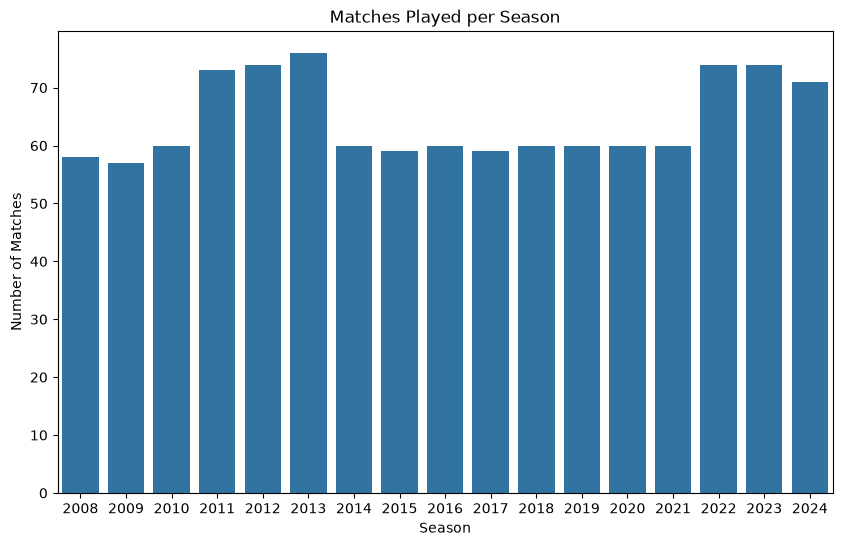

In [27]:
# performing EDA 

plt.figure(figsize = (10,6))
sns.countplot(x = 'season' , data = matches)
plt.title("Matches Played per Season")
plt.xlabel("Season")
plt.ylabel("Number of Matches")
plt.show()

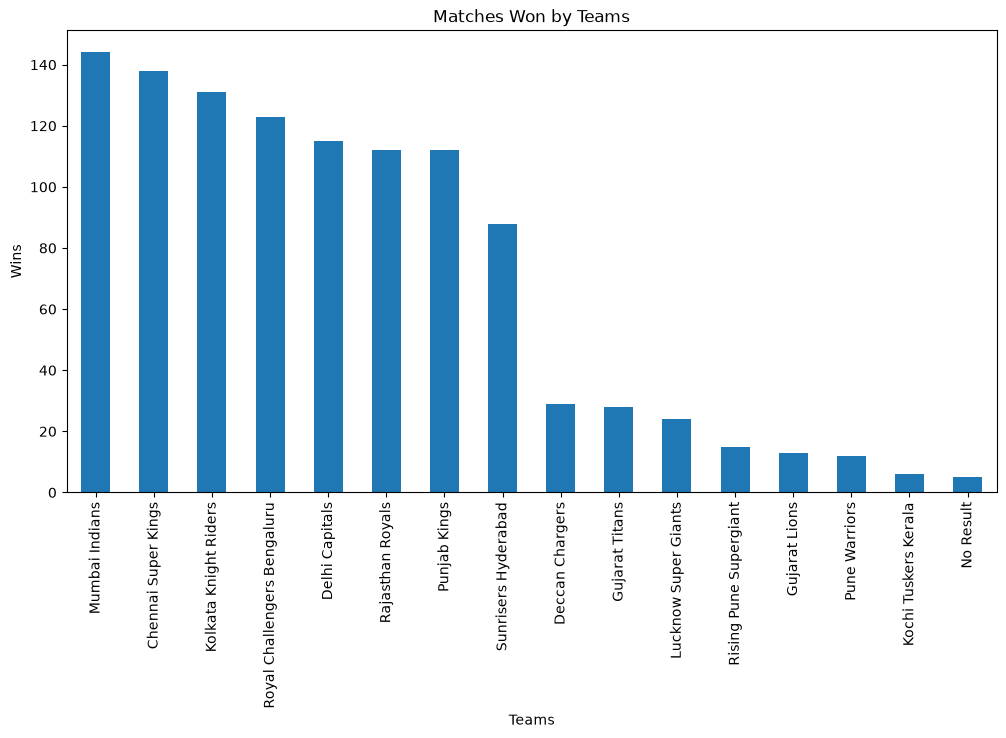

In [28]:
plt.figure(figsize = (12,6))
matches['winner'].value_counts().plot(kind = 'bar')
plt.title("Matches Won by Teams")
plt.xlabel("Teams")
plt.ylabel("Wins")
plt.show()

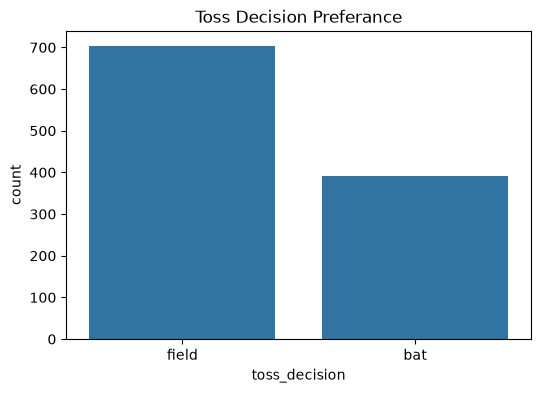

In [29]:
plt.figure(figsize = (6,4))
sns.countplot(x = "toss_decision" , data = matches)
plt.title("Toss Decision Preferance")
plt.show()

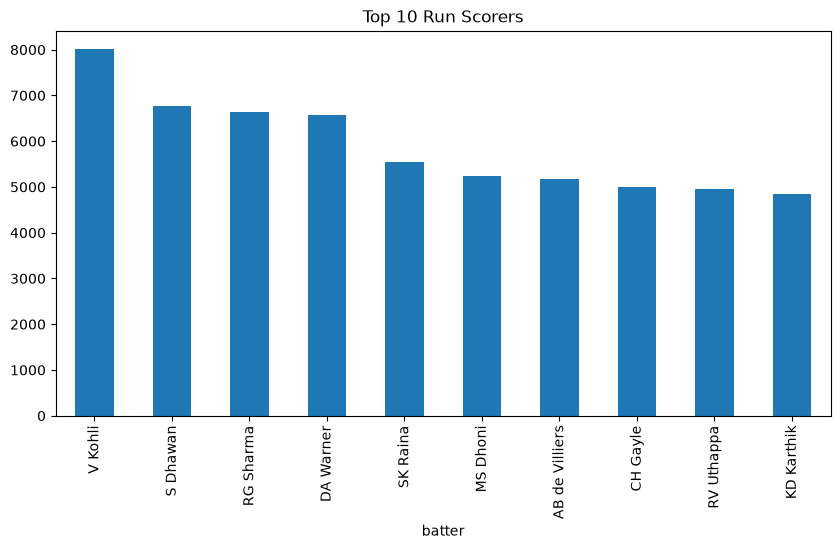

In [30]:
top_runs = deliveries.groupby('batter')['batsman_runs'].sum()
top_runs = top_runs.sort_values(ascending =  False).head(10)
plt.figure(figsize = (10,5))
top_runs.plot(kind = 'bar')
plt.title("Top 10 Run Scorers")
plt.show()

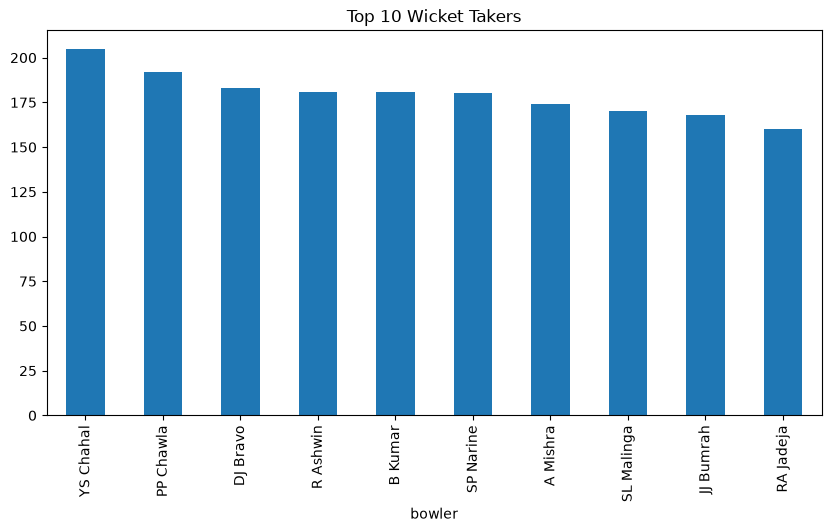

In [31]:
wickets = deliveries[
    (deliveries['player_dismissed'].notna()) &
    (deliveries['dismissal_kind'] != 'run out')
]
top_wickets = wickets.groupby('bowler').size().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
top_wickets.plot(kind='bar')
plt.title("Top 10 Wicket Takers")
plt.show()

In [32]:
# MySQL Connection
username = 'root'
password = 'abhijit45'
host = 'localhost'
port = '3306'
database = 'ipl'

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

# Load Matches table
matches.to_sql(
    name='matches',
    con=engine,
    if_exists='replace',
    index=False
)

# Load Deliveries table
deliveries.to_sql(
    name='deliveries',
    con=engine,
    if_exists='replace',
    index=False
)

print("Both tables loaded successfully!")

Both tables loaded successfully!


In [33]:
matches.to_csv(r"C:\Users\Abhijit\Downloads\ipl matches.csv", index=False)

deliveries.to_csv(r"C:\Users\Abhijit\Downloads\ipl deliveries.csv", index=False)

In [34]:
matches.tail()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,...,method,umpire1,umpire2,year,month,day,weekend_match,toss_match_winner,win_type,total_boundaries
1090,1426307,2024,Hyderabad,2024-05-19,League,Abhishek Sharma,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Punjab Kings,Sunrisers Hyderabad,Punjab Kings,...,Normal Match,Nitin Menon,VK Sharma,2024,May,Sunday,True,False,Chase,57
1091,1426309,2024,Ahmedabad,2024-05-21,Qualifier 1,MA Starc,"Narendra Modi Stadium, Ahmedabad",Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,...,Normal Match,AK Chaudhary,R Pandit,2024,May,Tuesday,False,False,Chase,45
1092,1426310,2024,Ahmedabad,2024-05-22,Eliminator,R Ashwin,"Narendra Modi Stadium, Ahmedabad",Royal Challengers Bengaluru,Rajasthan Royals,Rajasthan Royals,...,Normal Match,KN Ananthapadmanabhan,MV Saidharshan Kumar,2024,May,Wednesday,False,True,Chase,46
1093,1426311,2024,Chennai,2024-05-24,Qualifier 2,Shahbaz Ahmed,"MA Chidambaram Stadium, Chepauk, Chennai",Sunrisers Hyderabad,Rajasthan Royals,Rajasthan Royals,...,Normal Match,Nitin Menon,VK Sharma,2024,May,Friday,False,False,Bat First,38
1094,1426312,2024,Chennai,2024-05-26,Final,MA Starc,"MA Chidambaram Stadium, Chepauk, Chennai",Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,...,Normal Match,J Madanagopal,Nitin Menon,2024,May,Sunday,True,False,Chase,27
